# Diabetes Prediction

## Load the dataset

In [66]:
import pandas as pd
df = pd.read_csv('diabetes.csv')

## Exploratory data analysis

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

### Visualize corelation

* df.corr -> Will create a heatmap
* annot -> annotation need to be true to get all the value in the heatmap




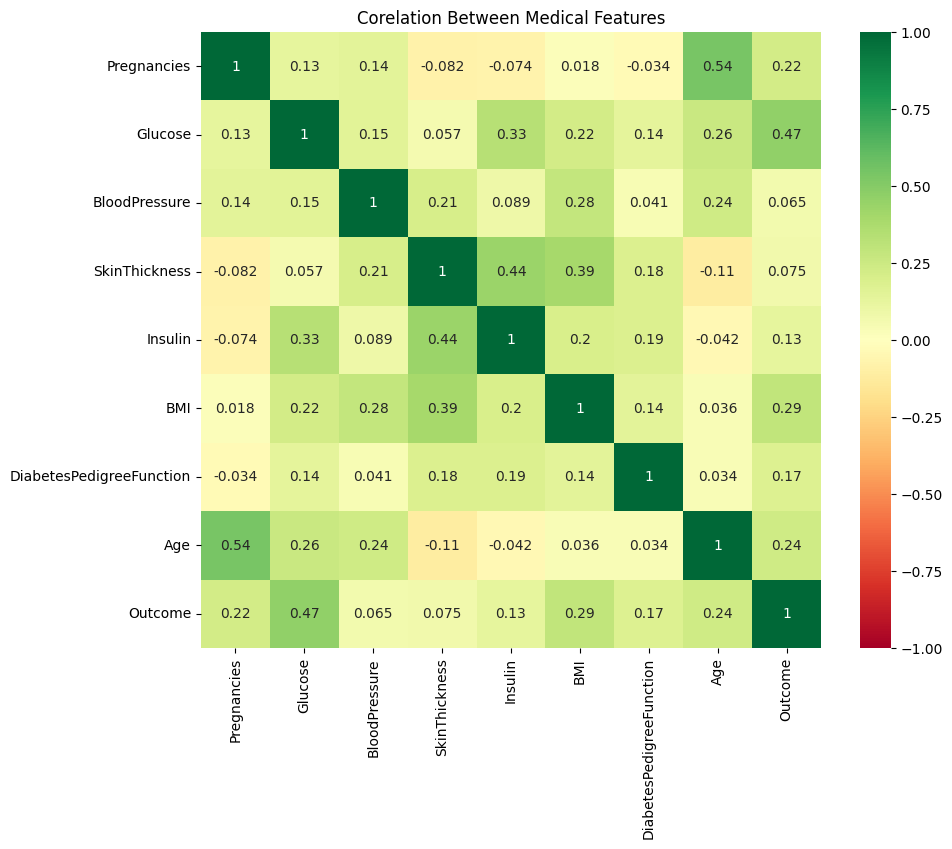

In [68]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='RdYlGn',center=0, vmin=-1, vmax=1)
plt.title("Corelation Between Medical Features")
plt.show()

## Data Preposessing

In [69]:
import numpy as np

In [70]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',	'BMI']

In [71]:
df[cols_to_fix] = df[cols_to_fix].replace(0,np.nan)

In [72]:
df.fillna(df.median(), inplace=True)

## Creating a matrix of the features and the dependent variable vector


In [73]:
x = df.drop("Outcome", axis = 1)
# x = df.iloc[:, :-1]
y = df["Outcome"]


## Splitting the dataset into the training set and the test set

In [74]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

## Feature scaling

In [75]:
# Scale the data so large members (like glucose) don't dominate small numbers (like pregnencies)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [76]:
x_train = sc.fit_transform(x_train)

In [77]:
x_test = sc.transform(x_test)

## Training the model

In [78]:
# n_extimatores is used to tell how many tree we need..
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 300, random_state = 42)

In [79]:
classifier.fit(x_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

## Predicting the test set result

In [80]:
y_pred = classifier.predict(x_test)

## Model Evaluation

In [81]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [82]:
print(confusion_matrix(y_test, y_pred))
accuracy_score(y_test, y_pred)

[[94 13]
 [15 32]]


0.8181818181818182

In [83]:
accuracy_score(y_test, y_pred)

0.8181818181818182

For the better acuracy score, we need to do the k-4 cross validation. will know more about this.


## Predicting a new patient

In [84]:
# example: Pragnencies =2 , glucose = 120, BP = 70, Skin Thikness = 30 , Insulin = 80, BMI = 25.6, DP = 0.5, Age = 32

new_data = np.array([[2, 120, 70, 30, 80, 25.6, 0.5, 32]])
# For scaling
new_data_scaled = sc.transform(new_data)

prediction = classifier.predict(new_data_scaled)
print(prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [85]:
if prediction[0] == 1:
  print("The model predict the patient has dibetes")
else:
  print("The model predict the patient does not have dibates")

The model predict the patient does not have dibates


## Selecting the most important feature

In [86]:
df.corr()["Outcome"].sort_values(ascending = False)

,Outcome
Outcome,1.000000
Glucose,0.492782
BMI,0.312038
Age,0.238356
Pregnancies,0.221898
SkinThickness,0.214873
Insulin,0.203790
DiabetesPedigreeFunction,0.173844
BloodPressure,0.165723


In [95]:
importances = classifier.feature_importances_
feature_names = x.columns
Feature_import_df = pd.DataFrame({"Feature" : feature_names, "Importances": importances}).sort_values("Importances", ascending = False)
print(Feature_import_df)

                    Feature  Importances
1                   Glucose     0.253426
5                       BMI     0.161242
7                       Age     0.138784
6  DiabetesPedigreeFunction     0.123119
4                   Insulin     0.086132
2             BloodPressure     0.084673
0               Pregnancies     0.077740
3             SkinThickness     0.074885


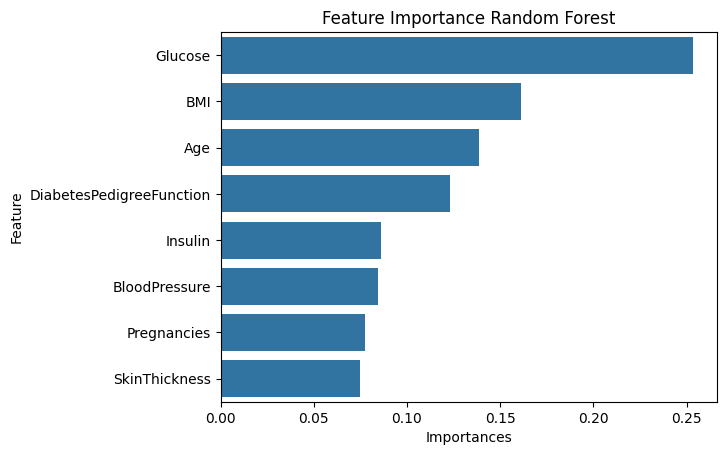

In [97]:
sns.barplot(x = "Importances", y = "Feature", data = Feature_import_df)
plt.title("Feature Importance Random Forest")
plt.show()


## Sensivity and specificity calculation

In [101]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[94, 13],
       [15, 32]])

In [100]:
tn, fp, fn, tp = cm.ravel()

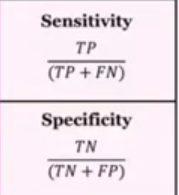

### Calculate sensitivity

The Question: Of all the people who actually have dibeties, how many did we catch?
**So, the more is better.**

In [111]:
sensitivity = tp/(tp+fn)
print(sensitivity)

0.6808510638297872


### Calculate Specificity

The question: Of all the healthy people, how many did we correctly identify as healthy?

In [110]:
specificity = tn / (tn + fp)
print(specificity)

0.8785046728971962
